In [50]:
print("Notebook Working!")

Notebook Working!


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.io import imread
from skimage.color import rgb2gray

In [52]:
mask_raw = imread("../data/976970_mask.png")

print("Shape:", mask_raw.shape)
print("Unique values:", np.unique(mask_raw))

Shape: (1024, 1024, 3)
Unique values: [  0 255]


In [53]:
gray = rgb2gray(mask_raw)
binary = gray > 0.5

print("Road pixels:", binary.sum())

Road pixels: 141409


In [54]:
skeleton = skeletonize(binary)

print("Skeleton pixels:", skeleton.sum())
print("How much thinner:", round(binary.sum() / skeleton.sum(), 1), "x")

Skeleton pixels: 11268
How much thinner: 12.5 x


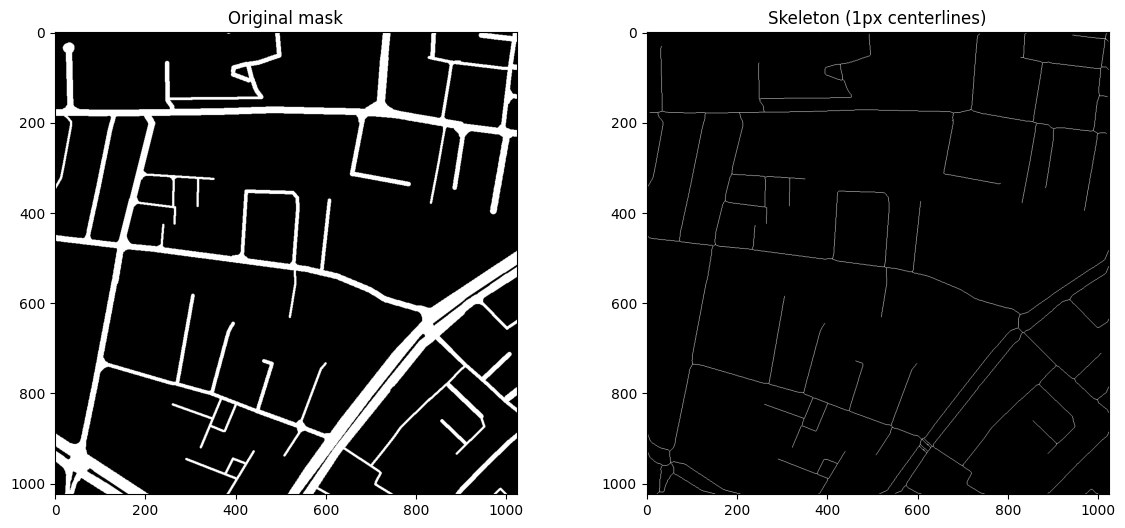

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title("Original mask")

axes[1].imshow(skeleton, cmap='gray')
axes[1].set_title("Skeleton (1px centerlines)")

plt.savefig("../outputs/skeleton_result.png")
plt.show()

In [56]:
from pathlib import Path

mask_dir = Path("../data/")
mask_files = list(mask_dir.glob("*_mask.png"))[:5]

for mf in mask_files:
    raw = imread(str(mf))
    gray = rgb2gray(raw) if raw.ndim == 3 else raw / 255.0
    binary = gray > 0.5
    skel = skeletonize(binary)
    ratio = round(binary.sum() / max(skel.sum(), 1), 1)
    print(f"{mf.name:35s}  road px: {binary.sum():7d}  skel px: {skel.sum():6d}  ratio: {ratio}x")

9663_mask.png                        road px:   56826  skel px:   4397  ratio: 12.9x
966525_mask.png                      road px:   86155  skel px:   5204  ratio: 16.6x
969845_mask.png                      road px:   54193  skel px:   3790  ratio: 14.3x
97272_mask.png                       road px:  125952  skel px:   8082  ratio: 15.6x
976970_mask.png                      road px:  141409  skel px:  11268  ratio: 12.5x


In [57]:
import sys
sys.path.append("../src")

from graph.skeleton import mask_to_graph
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np

mask_raw = imread("../data/966525_mask.png")   # your file name here
gray = rgb2gray(mask_raw) if mask_raw.ndim == 3 else mask_raw / 255.0
mask = (gray > 0.5).astype(np.uint8) * 255

result = mask_to_graph(mask)
print("Nodes:", len(result["nodes"]))
print("Edges:", len(result["edges"]))

Nodes: 41
Edges: 36


In [58]:
# First node
first_node_id = list(result["nodes"].keys())[0]
print("Node:", first_node_id, "→", result["nodes"][first_node_id])

# First edge
e = result["edges"][0]
print("Edge:", e["from"], "→", e["to"])
print("Length:", round(e["length_px"], 2), "pixels")
print("Path points:", len(e["pixel_path"]))

Node: 0 → {'pixel_coord': (0, 503)}
Edge: 0 → 2
Length: 68.63 pixels
Path points: 63


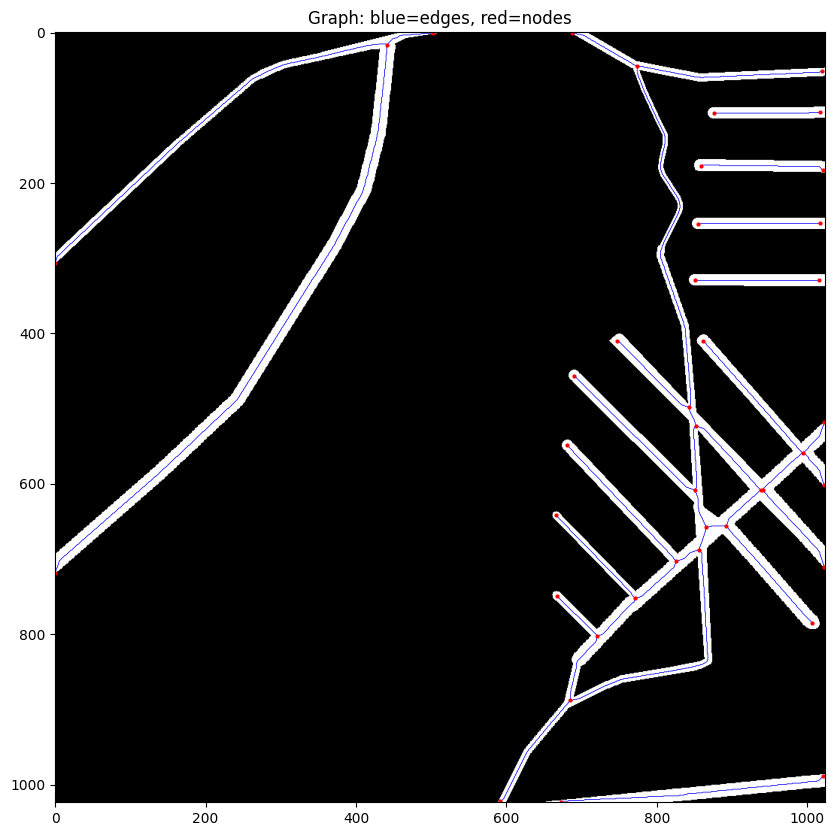

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask, cmap='gray')

# Draw edges
for edge in result["edges"]:
    pts = edge["pixel_path"]
    xs = [p[1] for p in pts]
    ys = [p[0] for p in pts]
    ax.plot(xs, ys, 'b-', linewidth=0.5)

# Draw nodes
for nid, ndata in result["nodes"].items():
    r, c = ndata["pixel_coord"]
    ax.plot(c, r, 'r.', markersize=4)

ax.set_title("Graph: blue=edges, red=nodes")
plt.savefig("../outputs/graph_result.png")
plt.show()

In [60]:
import sys
sys.path.append("../src")

from graph.graph_builder import graph_from_png
import networkx as nx

G = graph_from_png("../data/966525_mask.png")  # use any mask file you have

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 41
Edges: 36


In [61]:
# Look at first node
node_id = list(G.nodes)[0]
print("Node:", node_id)
print("Attributes:", G.nodes[node_id])

# Look at first edge
u, v, data = list(G.edges(data=True))[0]
print("\nEdge:", u, "→", v)
print("Length px:", round(data["length_px"], 2))
print("Length m: ", round(data["length_m"], 2))

Node: 0
Attributes: {'lat': 0.0, 'lon': 503.0, 'pixel_row': 0, 'pixel_col': 503}

Edge: 0 → 2
Length px: 68.63
Length m:  68.63


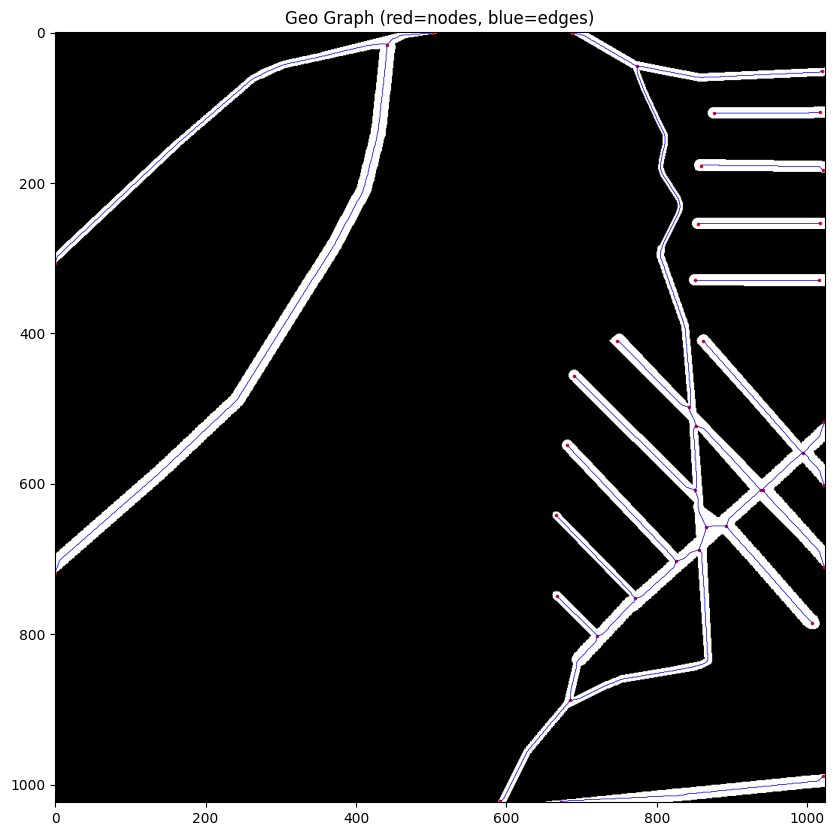

In [62]:
import matplotlib.pyplot as plt
from skimage.io import imread

img = imread("../data/966525_mask.png")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, cmap='gray')

for node_id, ndata in G.nodes(data=True):
    ax.plot(ndata["pixel_col"], ndata["pixel_row"], 'r.', markersize=3)

for u, v, edata in G.edges(data=True):
    pts = edata["pixel_path"]
    xs = [p[1] for p in pts]
    ys = [p[0] for p in pts]
    ax.plot(xs, ys, 'b-', linewidth=0.5)

ax.set_title("Geo Graph (red=nodes, blue=edges)")
plt.savefig("../outputs/geo_graph_result.png")
plt.show()

In [65]:
import importlib
import src.graph.healing
importlib.reload(src.graph.healing)
from src.graph.healing import heal_graph

g_healed = heal_graph(G, angle_threshold_deg=45.0, max_fallback=5)

bridges = [(u, v) for u, v, d in g_healed.edges(data=True) if d.get('bridge')]
print(f"Components before healing: {len(list(nx.connected_components(G)))}")
print(f"Components after healing:  {len(list(nx.connected_components(g_healed)))}")
print(f"Bridges added: {len(bridges)}")

[healing] Bridge added: node 3 ↔ node 6  (dist=119.36px)
[healing] No valid bridge within 45.0° for component pair (2, 3). Tried 4 candidate(s).
[healing] Warning: stopped with 6 disconnected component(s). No valid bridge found within angle constraint and fallback limit=5.
Components before healing: 7
Components after healing:  6
Bridges added: 1


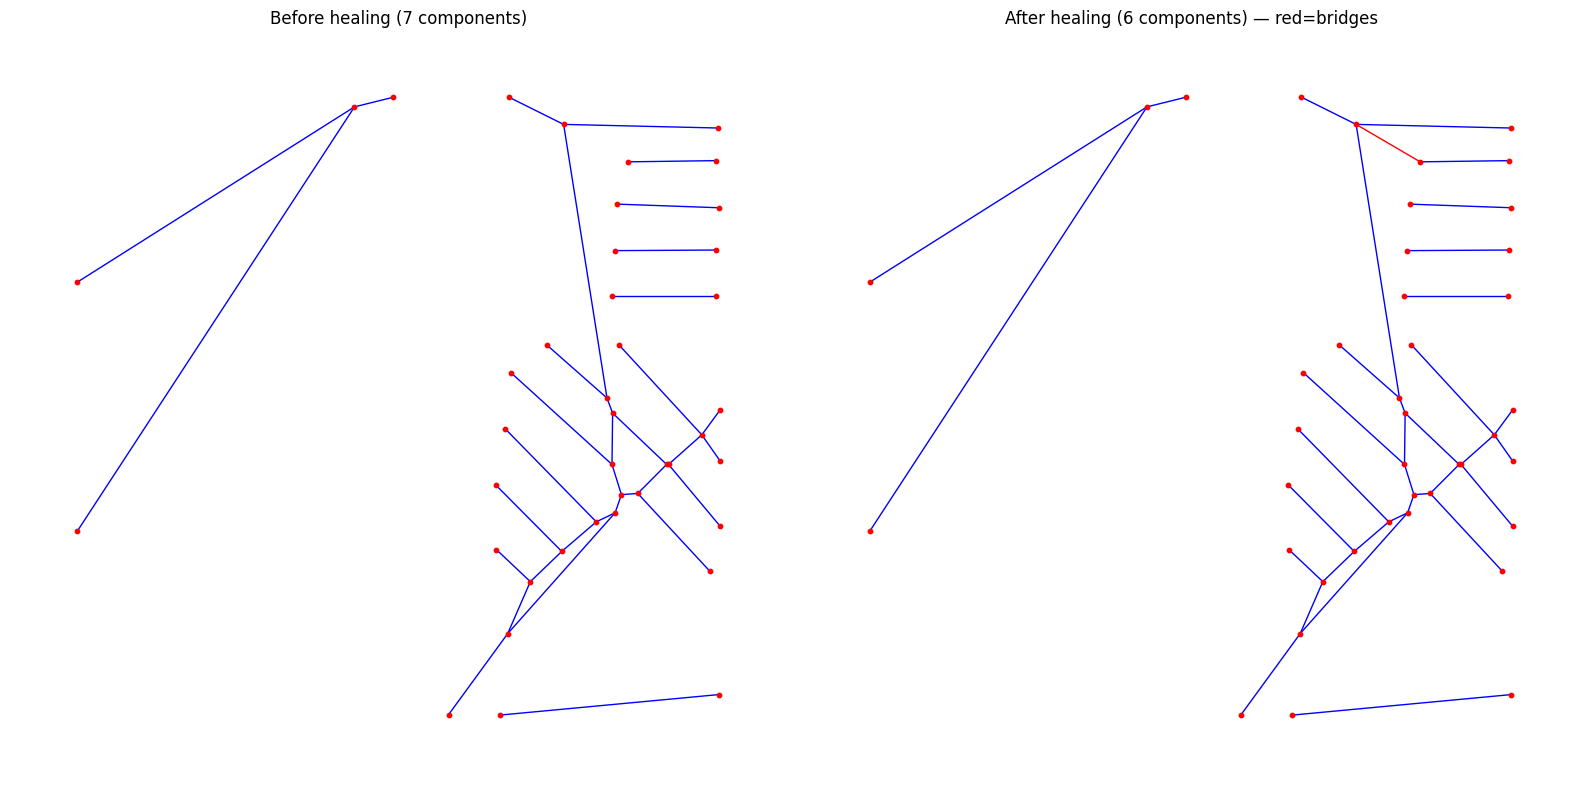

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Original
ax1 = axes[0]
nx.draw(G, pos={n: (d['pixel_col'], -d['pixel_row']) for n, d in G.nodes(data=True)},
        ax=ax1, node_size=10, edge_color='blue', node_color='red', width=1)
ax1.set_title(f"Before healing ({len(list(nx.connected_components(G)))} components)")

# Healed
ax2 = axes[1]
edge_colors = ['red' if d.get('bridge') else 'blue' 
               for u, v, d in g_healed.edges(data=True)]
nx.draw(g_healed, pos={n: (d['pixel_col'], -d['pixel_row']) for n, d in g_healed.nodes(data=True)},
        ax=ax2, node_size=10, edge_color=edge_colors, node_color='red', width=1)
ax2.set_title(f"After healing ({len(list(nx.connected_components(g_healed)))} components) — red=bridges")

plt.tight_layout()
plt.show()

In [67]:
from src.graph.skeleton import mask_to_graph

result = mask_to_graph(mask)   # your existing mask variable

print(f"Total edges: {len(result['edges'])}")
print(f"\nTop-10 critical road segments:")
for i, e in enumerate(result['critical_edges'], 1):
    print(f"  #{i}  edge {e['from']}→{e['to']}  "
          f"centrality={e['betweenness_centrality']}  "
          f"length={e['length_px']:.1f}px")

Total edges: 36

Top-10 critical road segments:
  #1  edge 28→29  centrality=0.197561  length=34.0px
  #2  edge 29→30  centrality=0.185366  length=36.2px
  #3  edge 24→25  centrality=0.153659  length=3.0px
  #4  edge 30→34  centrality=0.153659  length=78.2px
  #5  edge 27→28  centrality=0.146341  length=26.8px
  #6  edge 17→19  centrality=0.134146  length=28.7px
  #7  edge 23→28  centrality=0.134146  length=56.0px
  #8  edge 25→27  centrality=0.119512  length=69.2px
  #9  edge 21→24  centrality=0.112195  length=73.5px
  #10  edge 34→36  centrality=0.112195  length=74.2px


In [68]:
import importlib
import src.graph.healing
importlib.reload(src.graph.healing)
from src.graph.healing import heal_graph

result = heal_graph(G, angle_threshold_deg=45.0, max_fallback=5)

# Unpack
g_healed           = result['graph']
components_before  = result['components_before']
components_after   = result['components_after']
connectivity_ratio = result['connectivity_ratio']

print(f"Components before:  {components_before}")
print(f"Components after:   {components_after}")
print(f"Connectivity ratio: {connectivity_ratio}%")

bridges = [(u,v) for u,v,d in g_healed.edges(data=True) if d.get('bridge')]
print(f"Bridges added:      {len(bridges)}")

[healing] Bridge added: node 3 ↔ node 6  (dist=119.36px)
[healing] No valid bridge within 45.0° for component pair (2, 3). Tried 4 candidate(s).
[healing] Warning: stopped with 6 disconnected component(s). No valid bridge found within angle constraint and fallback limit=5.
[healing] Components before: 7  after: 6  connectivity_ratio: 14.3%
Components before:  7
Components after:   6
Connectivity ratio: 14.29%
Bridges added:      1
